In [7]:
import pandas as pd
import numpy as np
import seaborn as sns

In [8]:
data = pd.read_csv('../bitcoin_data/btc_binance_daily.csv')
data.head()


,date,open,high,low,close,volume
0,2023-09-16,26599.99,26777.00,26445.00,26559.67,13960.93351
1,2023-09-17,26559.67,26623.25,26399.00,26527.51,12998.10277
2,2023-09-18,26527.50,27409.00,26377.35,26762.51,43000.43256
3,2023-09-19,26762.50,27483.57,26667.79,27210.26,36190.52187
4,2023-09-20,27210.25,27388.63,26800.00,27125.00,34207.21867


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1000 non-null   str    
 1   open    1000 non-null   float64
 2   high    1000 non-null   float64
 3   low     1000 non-null   float64
 4   close   1000 non-null   float64
 5   volume  1000 non-null   float64
dtypes: float64(5), str(1)
memory usage: 47.0 KB


In [10]:
## take values for 3 decimal
cols = ["open", "high", "low", "close", "volume"]

data[cols] = data[cols].astype(float).round(3)

In [11]:
data.head()

,date,open,high,low,close,volume
0,2023-09-16,26599.99,26777.00,26445.00,26559.67,13960.934
1,2023-09-17,26559.67,26623.25,26399.00,26527.51,12998.103
2,2023-09-18,26527.50,27409.00,26377.35,26762.51,43000.433
3,2023-09-19,26762.50,27483.57,26667.79,27210.26,36190.522
4,2023-09-20,27210.25,27388.63,26800.00,27125.00,34207.219


In [12]:
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)

In [13]:
df = data.copy()

In [14]:
### Check duplicate values
duplicate_rows = df[df.duplicated()]

print("Number of duplicate rows:", duplicate_rows.shape[0])
print(duplicate_rows)

Number of duplicate rows: 0
Empty DataFrame
Columns: [date, open, high, low, close, volume]
Index: []


In [15]:
### Check missing values
missing_values = df.isnull().sum()
print("Number of missing values:", missing_values)


Number of missing values: date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [16]:
### Statistical overview

summary = df.drop(columns=["date"]).describe().round(3)
print(summary)

             open        high         low       close      volume
count    1000.000    1000.000    1000.000    1000.000    1000.000
mean    77163.065   78527.891   75731.818   77199.740   27660.586
std     24583.530   24836.965   24240.291   24535.328   18602.239
min     26221.680   26397.460   25990.460   26221.670    3104.117
25%     62079.002   63426.162   60653.502   62123.102   15467.079
50%     74020.460   75479.880   73080.750   74020.455   23092.700
75%     96847.298   98288.750   95208.090   96847.300   34445.785
max    124658.540  126199.630  123084.000  124658.540  162065.592


* Check zero or negative values

In [17]:
cols = ["open", "high", "low", "close", "volume"]

invalid_values = df[(df[cols] <= 0).any(axis=1)]

print(invalid_values)

Empty DataFrame
Columns: [date, open, high, low, close, volume]
Index: []


* Check outliers

In [18]:
df["daily_return_temp"] = df["close"].pct_change()

outliers = df[abs(df["daily_return_temp"]) > 0.20]

print(outliers[["date", "close", "daily_return_temp"]])

Empty DataFrame
Columns: [date, close, daily_return_temp]
Index: []


In [19]:
df = df.sort_values("date").reset_index(drop=True)

### Feature Engineering

* Log Return Features

In [20]:
periods = [1, 2, 5, 10]

for p in periods:
    col_name = "log_return" if p == 1 else f"log_return_{p}d"
    df[col_name] = np.log(df["close"] / df["close"].shift(p))

In [21]:
df[["log_return", "log_return_2d", "log_return_5d", "log_return_10d"]].isna().sum()

log_return         1
log_return_2d      2
log_return_5d      5
log_return_10d    10
dtype: int64

* Price Ratios

In [22]:
# Price ratios
df["high_low_ratio"] = df["high"] / df["low"]
df["close_open_ratio"] = df["close"] / df["open"]
df["high_close_ratio"] = df["high"] / df["close"]
df["low_close_ratio"] = df["low"] / df["close"]

# Daily range relative to close
df["range_ratio"] = (df["high"] - df["low"]) / df["close"]

# Candle body size relative to close
df["body_ratio"] = abs(df["close"] - df["open"]) / df["close"]

# Upper and lower shadow ratios
df["upper_shadow_ratio"] = (
    df["high"] - df[["open", "close"]].max(axis=1)
) / df["close"]

df["lower_shadow_ratio"] = (
    df[["open", "close"]].min(axis=1) - df["low"]
) / df["close"]

* Rolling Windows

In [23]:
# Rolling stats on log-return
return_windows = [7, 14, 30]

for w in return_windows:
    rolling_return = df["log_return"].rolling(window=w)

    df[f"return_mean_{w}d"] = rolling_return.mean()
    df[f"return_std_{w}d"] = rolling_return.std()
    df[f"return_skew_{w}d"] = rolling_return.skew()
    df[f"return_kurt_{w}d"] = rolling_return.kurt()

# Price distance from rolling highs / lows
price_windows = [7, 30, 90]

for w in price_windows:
    rolling_high = df["high"].rolling(window=w).max()
    rolling_low = df["low"].rolling(window=w).min()

    df[f"dist_from_high_{w}d"] = (df["close"] - rolling_high) / df["close"]
    df[f"dist_from_low_{w}d"] = (df["close"] - rolling_low) / df["close"]

In [24]:
from ta import momentum, trend


def add_momentum_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    RSI, MACD, Stochastic, ROC, Williams %R, CCI.
    Source: Jung et al. (2023) — Computer Systems Science & Engineering.
    """


    # RSI — multiple windows
    for w in [9, 14, 21]:
        df[f"rsi_{w}"] = momentum.RSIIndicator(
            close=df["close"],
            window=w
        ).rsi()

    # MACD
    macd_obj = trend.MACD(
        close=df["close"],
        window_slow=26,
        window_fast=12,
        window_sign=9
    )

    df["macd"] = macd_obj.macd()
    df["macd_signal"] = macd_obj.macd_signal()
    df["macd_hist"] = macd_obj.macd_diff()

    # Stochastic Oscillator
    for w in [9, 14, 21]:
        stoch_obj = momentum.StochasticOscillator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w,
            smooth_window=3
        )

        df[f"stoch_k_{w}"] = stoch_obj.stoch()
        df[f"stoch_d_{w}"] = stoch_obj.stoch_signal()

    # Rate of Change — ROC
    for w in [9, 14, 21]:
        df[f"roc_{w}"] = momentum.ROCIndicator(
            close=df["close"],
            window=w
        ).roc()

    # Williams %R
    for w in [9, 14, 21]:
        df[f"williams_r_{w}"] = momentum.WilliamsRIndicator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            lbp=w
        ).williams_r()

    # Commodity Channel Index — CCI
    for w in [14, 20, 30]:
        df[f"cci_{w}"] = trend.CCIIndicator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w,
            constant=0.015
        ).cci()

    return df

In [25]:
df = add_momentum_features(df)

print(df.head())

        date      open      high       low     close     volume  \
0 2023-09-16  26599.99  26777.00  26445.00  26559.67  13960.934   
1 2023-09-17  26559.67  26623.25  26399.00  26527.51  12998.103   
2 2023-09-18  26527.50  27409.00  26377.35  26762.51  43000.433   
3 2023-09-19  26762.50  27483.57  26667.79  27210.26  36190.522   
4 2023-09-20  27210.25  27388.63  26800.00  27125.00  34207.219   

   daily_return_temp  log_return  log_return_2d  log_return_5d  ...  \
0                NaN         NaN            NaN            NaN  ...   
1          -0.001211   -0.001212            NaN            NaN  ...   
2           0.008859    0.008820       0.007608            NaN  ...   
3           0.016730    0.016592       0.025412            NaN  ...   
4          -0.003133   -0.003138       0.013454            NaN  ...   

   stoch_d_21  roc_9  roc_14  roc_21  williams_r_9  williams_r_14  \
0         NaN    NaN     NaN     NaN           NaN            NaN   
1         NaN    NaN     NaN    

In [26]:
from ta import trend


def add_trend_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    SMA, EMA, TEMA, ADX, PSAR, Ichimoku.
    """


    # Simple Moving Averages
    for w in [7, 21, 50, 200]:
        df[f"sma_{w}"] = trend.SMAIndicator(
            close=df["close"],
            window=w
        ).sma_indicator()

        df[f"price_vs_sma_{w}"] = (
            df["close"] - df[f"sma_{w}"]
        ) / df[f"sma_{w}"]

    # Exponential Moving Averages
    for w in [9, 12, 26]:
        df[f"ema_{w}"] = trend.EMAIndicator(
            close=df["close"],
            window=w
        ).ema_indicator()

    # TEMA: Triple Exponential Moving Average
    for w in [9, 12, 26]:
        ema1 = df["close"].ewm(span=w, adjust=False).mean()
        ema2 = ema1.ewm(span=w, adjust=False).mean()
        ema3 = ema2.ewm(span=w, adjust=False).mean()

        df[f"tema_{w}"] = 3 * ema1 - 3 * ema2 + ema3

    # EMA / SMA crossover features
    df["ema_9_26_cross"] = df["ema_9"] - df["ema_26"]
    df["sma_50_200_cross"] = df["sma_50"] - df["sma_200"]

    # ADX: trend strength
    adx_obj = trend.ADXIndicator(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=14
    )

    df["adx"] = adx_obj.adx()
    df["adx_pos"] = adx_obj.adx_pos()
    df["adx_neg"] = adx_obj.adx_neg()

    # Parabolic SAR
    psar = trend.PSARIndicator(
        high=df["high"],
        low=df["low"],
        close=df["close"]
    )

    df["psar"] = psar.psar()
    df["psar_up"] = psar.psar_up()
    df["psar_down"] = psar.psar_down()

    # Ichimoku
    ichimoku = trend.IchimokuIndicator(
        high=df["high"],
        low=df["low"],
        window1=9,
        window2=26,
        window3=52
    )

    df["ichimoku_a"] = ichimoku.ichimoku_a()
    df["ichimoku_b"] = ichimoku.ichimoku_b()
    df["ichimoku_base"] = ichimoku.ichimoku_base_line()
    df["ichimoku_conv"] = ichimoku.ichimoku_conversion_line()

    return df

In [27]:
df = add_trend_features(df)

* Volatility Features

In [28]:
from ta import volatility


def add_volatility_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bollinger Bands, ATR, Keltner Channel, Donchian Channel.
    """


    # Make sure log_return exists
    if "log_return" not in df.columns:
        df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # Bollinger Bands
    for w in [14, 20]:
        bb = volatility.BollingerBands(
            close=df["close"],
            window=w,
            window_dev=2
        )

        df[f"bb_upper_{w}"] = bb.bollinger_hband()
        df[f"bb_lower_{w}"] = bb.bollinger_lband()
        df[f"bb_width_{w}"] = bb.bollinger_wband()
        df[f"bb_pct_{w}"] = bb.bollinger_pband()

    # Average True Range
    for w in [7, 14]:
        atr = volatility.AverageTrueRange(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w
        )

        df[f"atr_{w}"] = atr.average_true_range()
        df[f"atr_pct_{w}"] = df[f"atr_{w}"] / df["close"]

    # Keltner Channel
    kc = volatility.KeltnerChannel(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=20
    )

    df["kc_upper"] = kc.keltner_channel_hband()
    df["kc_lower"] = kc.keltner_channel_lband()
    df["kc_width"] = kc.keltner_channel_wband()

    # Donchian Channel
    dc = volatility.DonchianChannel(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=20
    )

    df["dc_upper"] = dc.donchian_channel_hband()
    df["dc_lower"] = dc.donchian_channel_lband()
    df["dc_width"] = dc.donchian_channel_wband()

    # Historical volatility annualized
    for w in [7, 14, 30]:
        df[f"hist_vol_{w}d"] = (
            df["log_return"].rolling(w).std() * np.sqrt(365)
        )

    return df

In [29]:
df = add_volatility_features(df)

/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_75954/1840597279.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"hist_vol_{w}d"] = (


In [30]:
df

,date,open,high,low,close,volume,daily_return_temp,log_return,log_return_2d,log_return_5d,...,atr_pct_14,kc_upper,kc_lower,kc_width,dc_upper,dc_lower,dc_width,hist_vol_7d,hist_vol_14d,hist_vol_30d
0,2023-09-16,26599.99,26777.00,26445.00,26559.67,13960.934,NaN,NaN,NaN,NaN,...,0.000000,26925.890000,26261.890000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-09-17,26559.67,26623.25,26399.00,26527.51,12998.103,-0.001211,-0.001212,NaN,NaN,...,0.000000,26833.363333,26277.113333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-09-18,26527.50,27409.00,26377.35,26762.51,43000.433,0.008859,0.008820,0.007608,NaN,...,0.000000,27182.665556,26124.065556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-09-19,26762.50,27483.57,26667.79,27210.26,36190.522,0.016730,0.016592,0.025412,NaN,...,0.000000,27371.079167,26169.239167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-09-20,27210.25,27388.63,26800.00,27125.00,34207.219,-0.003133,-0.003138,0.013454,NaN,...,0.000000,27435.498000,26238.574000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026-06-07,60884.62,64234.68,60746.00,63332.01,26612.104,0.040197,0.039410,0.036592,-0.052726,...,0.040509,74307.073500,69496.569500,6.690378,78200.0,59130.91,26.574008,0.673961,0.499465,0.406338
996,2026-06-08,63332.01,64200.00,62408.00,63085.99,23053.386,-0.003885,-0.003892,0.035518,-0.016612,...,0.039791,73654.849667,68792.136667,6.827400,78200.0,59130.91,26.831039,0.679109,0.493750,0.403530
997,2026-06-09,63086.00,63526.01,60780.00,61730.00,21636.220,-0.021494,-0.021729,-0.025621,-0.034330,...,0.040938,72960.568500,67956.884500,7.101582,78200.0,59130.91,27.133065,0.542629,0.494820,0.394045
998,2026-06-10,61730.00,62857.99,60755.00,61510.99,15998.717,-0.003548,-0.003554,-0.025283,0.007417,...,0.040591,72201.508000,67135.578000,7.271474,78080.0,59130.91,27.274818,0.485742,0.497185,0.394376


In [31]:
# 1. Check which columns have missing values
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

psar_down            549
psar_up              453
sma_50_200_cross     199
price_vs_sma_200     199
sma_200              199
                    ... 
dist_from_high_7d      6
log_return_5d          5
log_return_2d          2
log_return             1
daily_return_temp      1
Length: 77, dtype: int64


In [32]:
# 2. Drop columns that are completely empty
all_nan_cols = df.columns[df.isna().all()].tolist()

print("Fully empty columns:", all_nan_cols)

df = df.drop(columns=all_nan_cols)

Fully empty columns: []


In [33]:
# 3. Fill PSAR direction columns instead of dropping rows
for col in ["psar_up", "psar_down"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

* Target Feature

In [34]:
df["target_pct_change"] = ((df["close"].shift(-1) / df["close"]) - 1) * 100

/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_75954/3724307980.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target_pct_change"] = ((df["close"].shift(-1) / df["close"]) - 1) * 100


In [35]:
before = len(df)

df_clean = df.dropna().reset_index(drop=True)

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows dropped:", before - after)

Rows before: 1000
Rows after: 800
Rows dropped: 200


In [36]:
# Drop rows where target is missing
df = df.dropna(subset=["target_pct_change"]).reset_index(drop=True)

In [37]:
df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)

Final shape: (800, 106)


In [38]:
# Select only numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation with target_pct_change
corr_with_target = numeric_df.corr()["target_pct_change"].sort_values(ascending=False)

print(corr_with_target)

target_pct_change     1.000000
upper_shadow_ratio    0.111274
high_close_ratio      0.081341
volume                0.063900
low_close_ratio       0.051845
                        ...   
ema_26               -0.050568
dc_lower             -0.052146
close                -0.052744
sma_50               -0.052781
bb_lower_20          -0.053249
Name: target_pct_change, Length: 105, dtype: float64


In [39]:
corr_with_target = corr_with_target.drop(
    labels=["target_pct_change"],
    errors="ignore"
)

print(corr_with_target.head(30))
print(corr_with_target.tail(30))

upper_shadow_ratio    0.111274
high_close_ratio      0.081341
volume                0.063900
low_close_ratio       0.051845
return_skew_14d       0.049691
atr_pct_14            0.046433
atr_pct_7             0.044815
return_kurt_14d       0.044205
kc_width              0.043623
return_skew_30d       0.043468
bb_width_20           0.040739
return_skew_7d        0.038251
bb_width_14           0.035032
hist_vol_14d          0.030012
return_std_14d        0.030012
dc_width              0.028915
hist_vol_30d          0.025133
return_std_30d        0.025133
range_ratio           0.020756
dist_from_low_90d     0.020301
cci_14                0.017926
high_low_ratio        0.014943
stoch_d_14            0.014007
stoch_k_14            0.012606
williams_r_14         0.012606
macd_signal           0.012521
adx_pos               0.010773
williams_r_21         0.010322
stoch_k_21            0.010322
cci_20                0.008876
Name: target_pct_change, dtype: float64
sma_200             -0.044371


In [40]:
corr_abs = corr_with_target.abs().sort_values(ascending=False)

print(corr_abs.head(30))

upper_shadow_ratio    0.111274
high_close_ratio      0.081341
volume                0.063900
bb_lower_20           0.053249
sma_50                0.052781
close                 0.052744
dc_lower              0.052146
low_close_ratio       0.051845
ema_26                0.050568
kc_lower              0.050395
dc_upper              0.050271
tema_9                0.049955
sma_21                0.049852
return_skew_14d       0.049691
ichimoku_base         0.049685
bb_lower_14           0.049620
kc_upper              0.049225
ema_12                0.048829
high                  0.048761
ema_9                 0.048651
open                  0.048642
tema_12               0.048623
log_return            0.048567
ichimoku_a            0.048399
price_vs_sma_7        0.048321
ichimoku_b            0.048069
low                   0.047939
close_open_ratio      0.047892
daily_return_temp     0.047891
sma_7                 0.047038
Name: target_pct_change, dtype: float64


### Split the data set

In [41]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

In [42]:
train_df = df.loc[: "2024-12-31"]
test_df = df.loc["2025-01-01" :]

In [43]:
print("Train period:", train_df.index.min(), "to", train_df.index.max())
print("Test period:", test_df.index.min(), "to", test_df.index.max())

Train period: 2024-04-02 00:00:00 to 2024-12-31 00:00:00
Test period: 2025-01-01 00:00:00 to 2026-06-10 00:00:00


In [44]:
drop_cols = ["target_pct_change"]

X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

y_train = train_df["target_pct_change"]
y_test = test_df["target_pct_change"]

### Train a baseline Model

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 1.8611167959596102
RMSE: 2.589929419506355
R2: -0.2308102889249639


### Check important feature

In [46]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(10))

               feature  importance
16  upper_shadow_ratio    0.065045
34  dist_from_high_90d    0.050145
41           macd_hist    0.045386
9       log_return_10d    0.032881
17  lower_shadow_ratio    0.029597
85         bb_width_14    0.023906
98            dc_upper    0.022653
45          stoch_d_14    0.022272
73                 adx    0.020805
83         bb_upper_14    0.020759


In [47]:
y_pred = model.predict(X_test)

In [48]:
comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
}, index=y_test.index)

comparison["error"] = comparison["actual"] - comparison["predicted"]
comparison["abs_error"] = comparison["error"].abs()

print(comparison.head(10))

              actual  predicted     error  abs_error
date                                                
2025-01-01  2.529818  -0.427228  2.957046   2.957046
2025-01-02  1.226368  -0.197983  1.424350   1.424350
2025-01-03  0.047181  -0.277131  0.324312   0.324312
2025-01-04  0.145703  -0.454899  0.600602   0.600602
2025-01-05  3.936405  -0.272850  4.209255   4.209255
2025-01-06 -5.165510  -0.285608 -4.879902   4.879902
2025-01-07 -1.953491   0.041007 -1.994498   1.994498
2025-01-08 -2.638443  -0.087818 -2.550625   2.550625
2025-01-09  2.348527   0.003263  2.345264   2.345264
2025-01-10 -0.133142   0.416330 -0.549472   0.549472


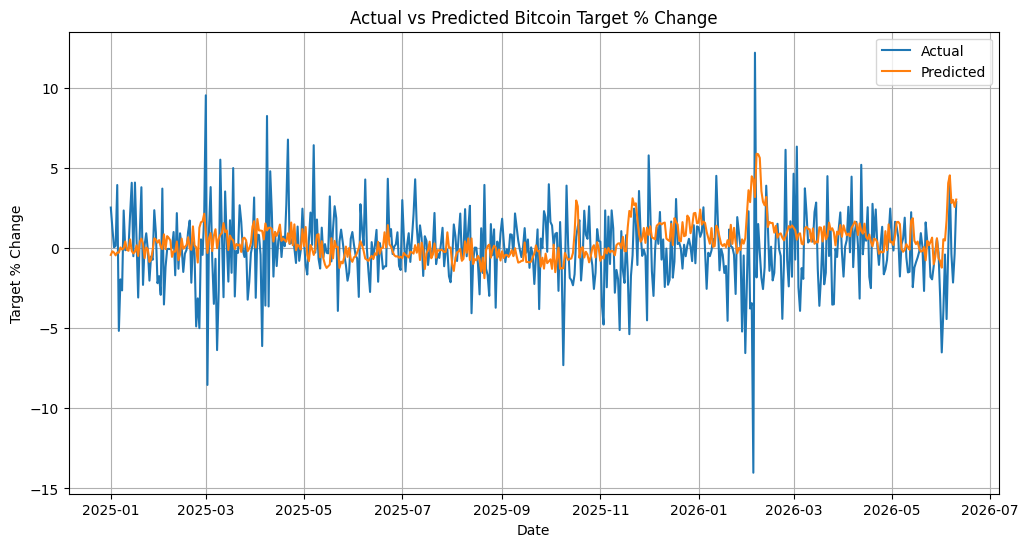

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(comparison.index, comparison["actual"], label="Actual")
plt.plot(comparison.index, comparison["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()

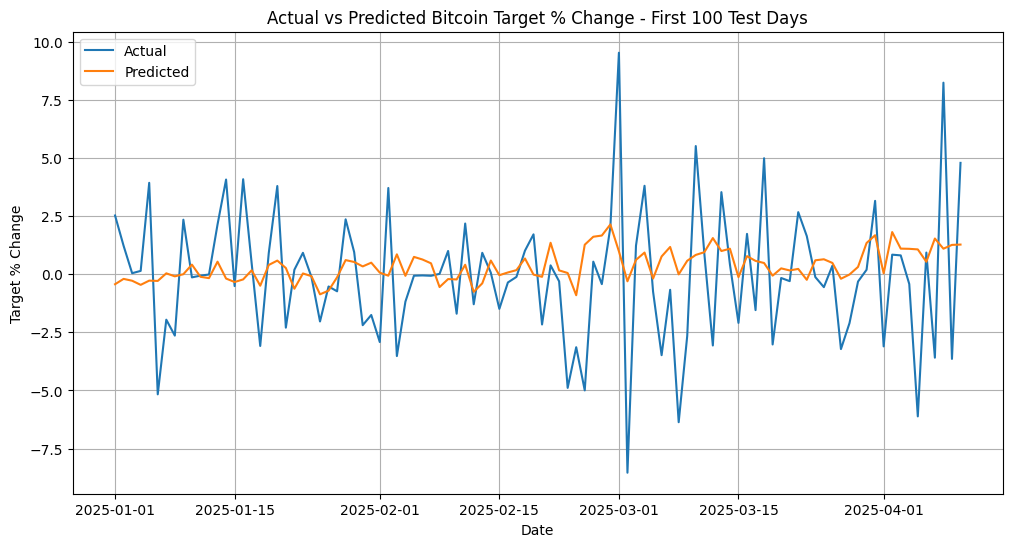

In [50]:
sample = comparison.head(100)

plt.figure(figsize=(12, 6))

plt.plot(sample.index, sample["actual"], label="Actual")
plt.plot(sample.index, sample["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change - First 100 Test Days")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()

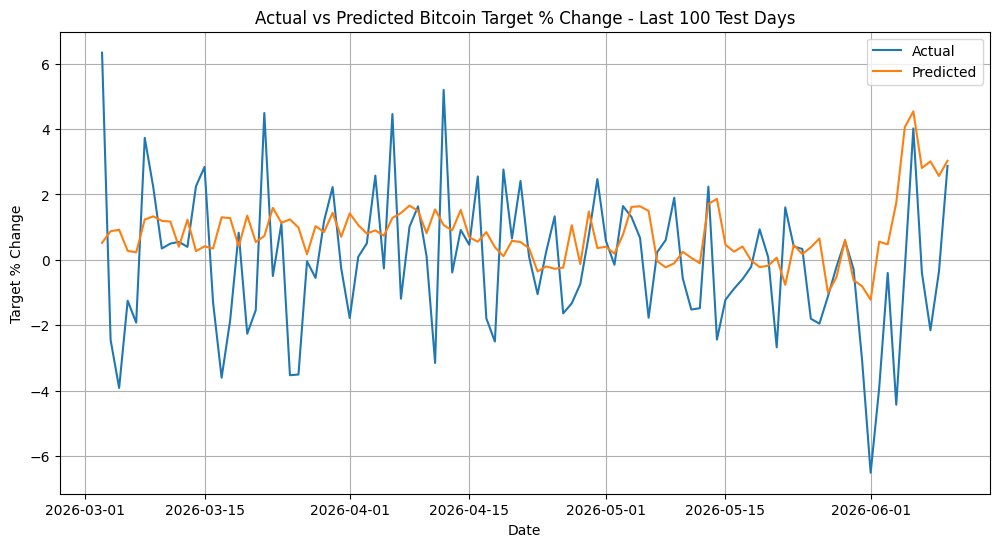

In [51]:
sample = comparison.tail(100)

plt.figure(figsize=(12, 6))

plt.plot(sample.index, sample["actual"], label="Actual")
plt.plot(sample.index, sample["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change - Last 100 Test Days")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()

KPI

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(comparison["actual"], comparison["predicted"])
rmse = np.sqrt(mean_squared_error(comparison["actual"], comparison["predicted"]))
r2 = r2_score(comparison["actual"], comparison["predicted"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.8611167959596102
RMSE: 2.589929419506355
R2: -0.2308102889249639


### XGBoost Model

In [53]:
from xgboost import XGBRegressor

In [54]:
xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [55]:
y_pred = xgb_reg.predict(X_test)

In [56]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

XGBoost Regression Results
MAE: 2.1644388477064553
RMSE: 2.953081184423899
R2: -0.6001696657917848
